Figure 1: Simulation vs Theory (baseline params)
Running baseline Gillespie...
Solving ODE theory...
Saved: oosawa_sim_vs_theory.png


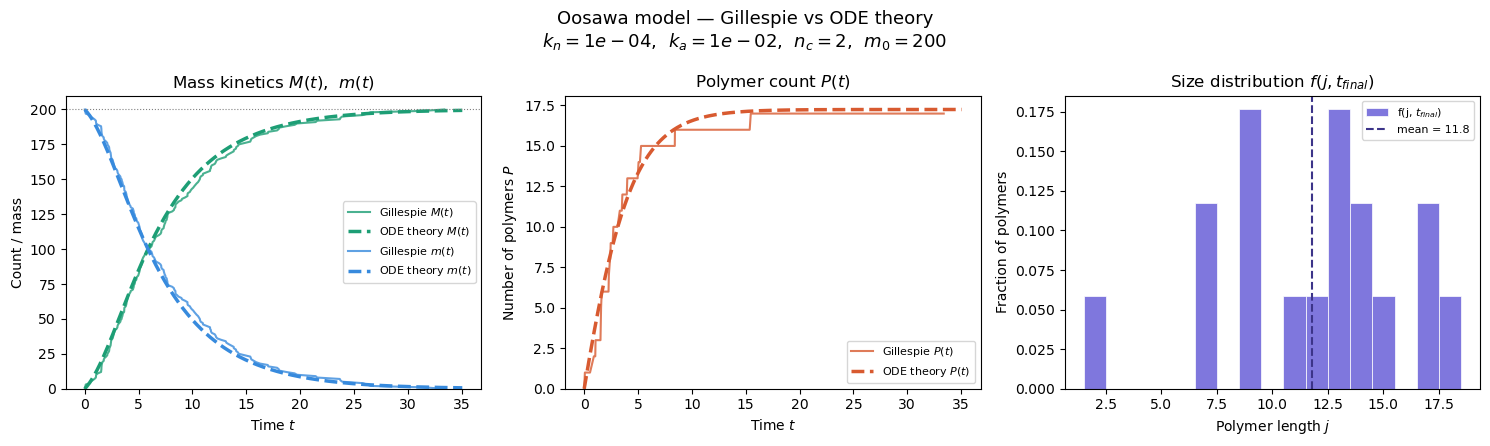


Figure 2: Parameter exploration (kn, ka, nc)
  Simulating row: kn
  Simulating row: ka
  Simulating row: nc
Saved: oosawa_parameter_exploration.png


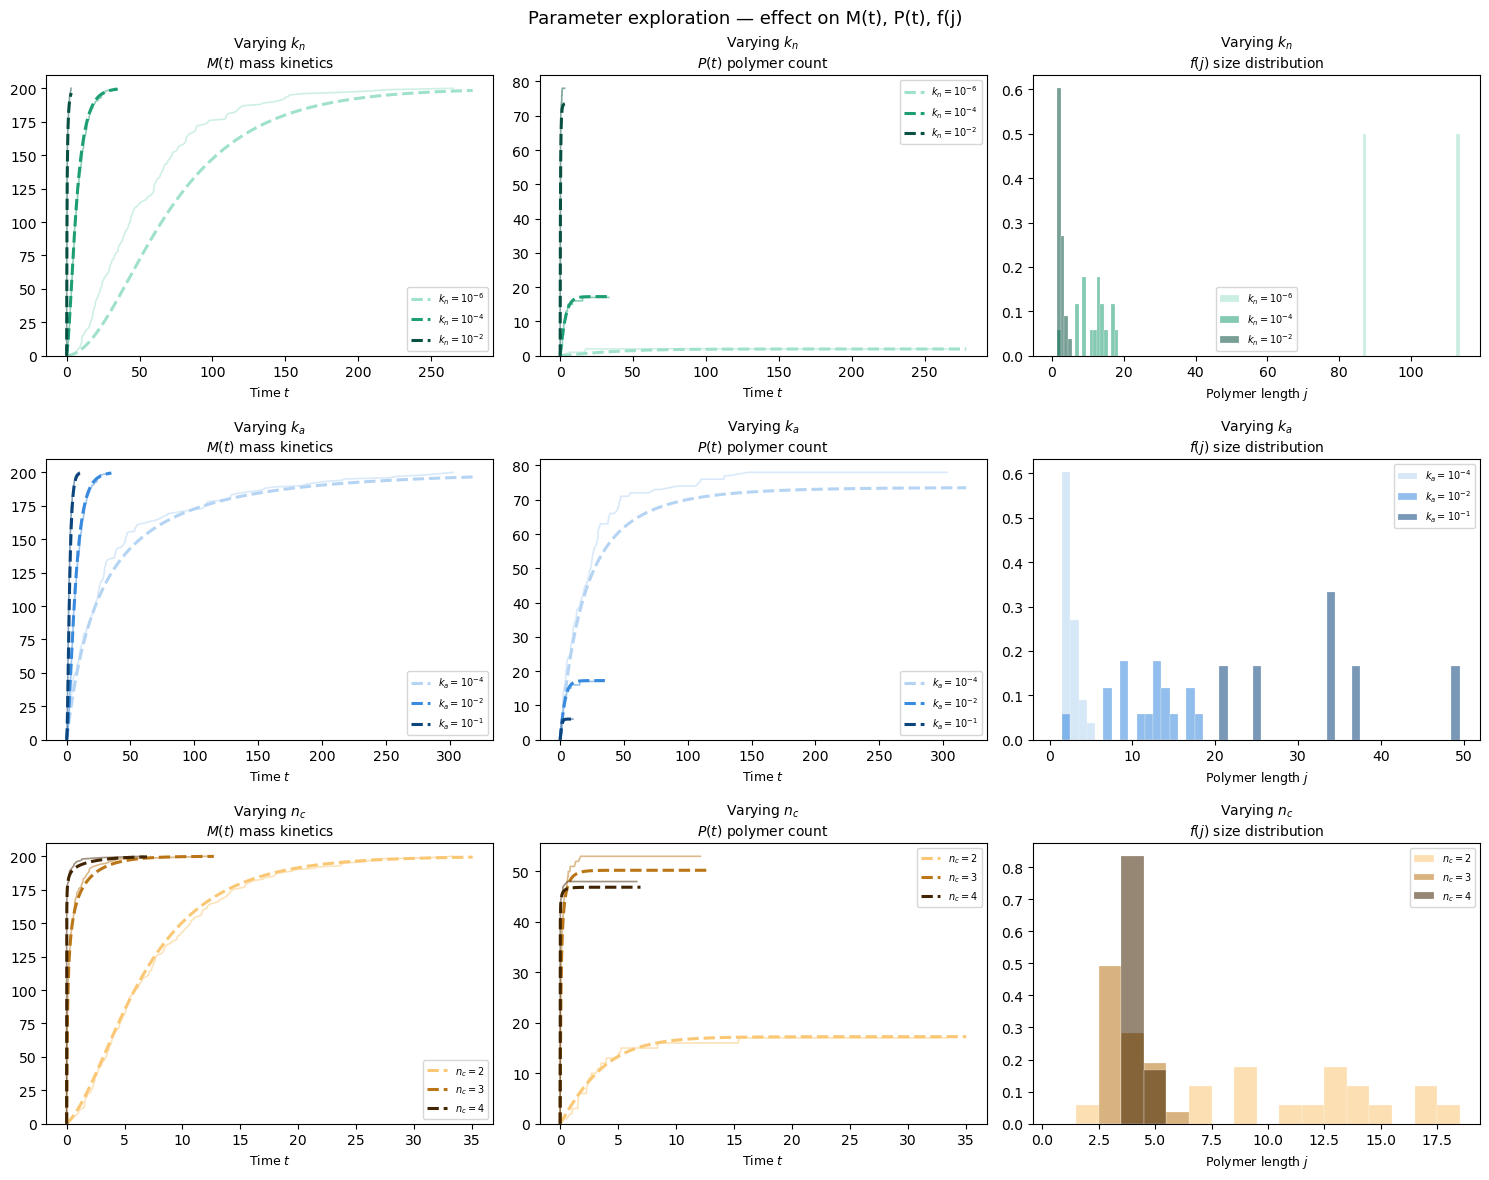


Figure 3: f(j,t) evolution in time
Running simulation for f(j,t) time evolution...
Saved: oosawa_fj_evolution.png


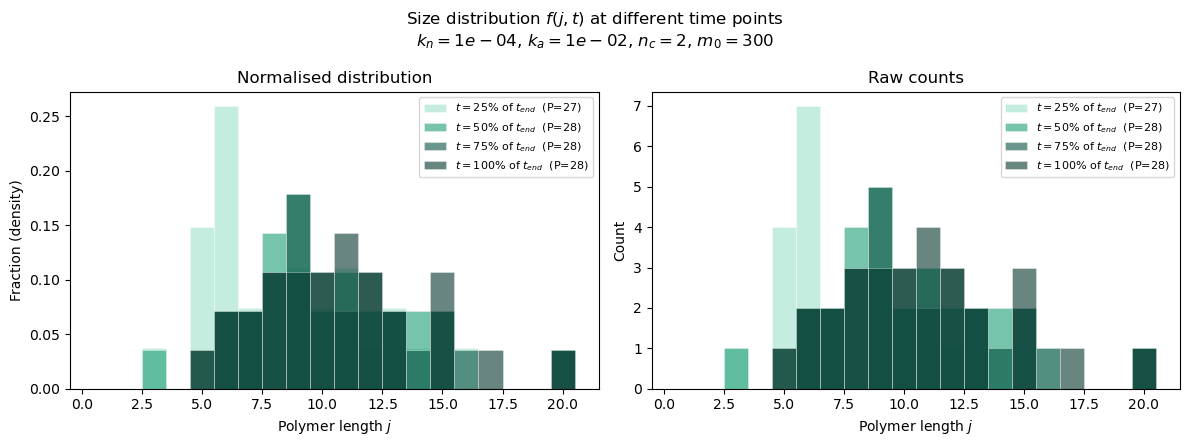

In [1]:
"""
Oosawa Model — Simulation vs Theory + Parameter exploration
============================================================
Week 1, Question 2: Compare Gillespie results with analytical solution
and explore how kn, ka, nc affect M(t), P(t), f(j,t).
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.integrate import solve_ivp

# ─────────────────────────────────────────────
# 1. GILLESPIE SIMULATION (tracks f(j,t) too)
# ─────────────────────────────────────────────

def gillespie_oosawa_full(kn, ka, nc, m0, max_events=200_000):
    """
    Full Gillespie simulation of the Oosawa model.
    Tracks individual polymer lengths to compute f(j, t_final).
    """
    t = 0.0
    m = m0
    P = 0
    M = 0
    polymers = []   # list of current polymer lengths

    t_series = [0.0]
    m_series = [m0]
    P_series = [0]
    M_series = [0]

    rng = np.random.default_rng(seed=42)

    for _ in range(max_events):
        r_nucl  = kn * (m ** nc) if m >= nc else 0.0
        r_assoc = ka * m * P     if m > 0 and P > 0 else 0.0
        r_total = r_nucl + r_assoc

        if r_total <= 0:
            break

        tau = -np.log(rng.random()) / r_total
        t  += tau

        u = rng.random()
        if u < r_nucl / r_total:
            # Nucleation: new polymer of size nc
            polymers.append(nc)
            m -= nc
            M += nc
            P += 1
        else:
            # Association: pick a random polymer and add one monomer
            idx = rng.integers(0, P)
            polymers[idx] += 1
            m -= 1
            M += 1

        t_series.append(t)
        m_series.append(m)
        P_series.append(P)
        M_series.append(M)

        if m <= 0:
            break

    return (np.array(t_series), np.array(m_series),
            np.array(P_series),  np.array(M_series),
            np.array(polymers))


# ─────────────────────────────────────────────
# 2. ANALYTICAL / ODE SOLUTION
# ─────────────────────────────────────────────

def odes_oosawa(t, y, kn, ka, nc, m0):
    """
    Moment equations of the Oosawa model:
      dP/dt = kn * m^nc
      dM/dt = nc*kn*m^nc + ka*m*P
      m(t)  = m0 - M(t)
    """
    P, M = y
    m = max(m0 - M, 0.0)
    dP = kn * (m ** nc)
    dM = nc * kn * (m ** nc) + ka * m * P
    return [dP, dM]


def solve_theory(kn, ka, nc, m0, t_end, n_points=500):
    t_eval = np.linspace(0, t_end, n_points)
    sol = solve_ivp(
        odes_oosawa, [0, t_end], [0.0, 0.0],
        args=(kn, ka, nc, m0),
        t_eval=t_eval, method='RK45',
        rtol=1e-8, atol=1e-10
    )
    P_th = sol.y[0]
    M_th = sol.y[1]
    m_th = m0 - M_th
    return sol.t, m_th, P_th, M_th


# ─────────────────────────────────────────────
# 3. FIGURE 1 — SIMULATION vs THEORY (baseline)
# ─────────────────────────────────────────────

def fig_sim_vs_theory():
    KN, KA, NC, M0 = 1e-4, 1e-2, 2, 200

    print("Running baseline Gillespie...")
    t_sim, m_sim, P_sim, M_sim, polymers = gillespie_oosawa_full(KN, KA, NC, M0)
    t_end = t_sim[-1] * 1.05

    print("Solving ODE theory...")
    t_th, m_th, P_th, M_th = solve_theory(KN, KA, NC, M0, t_end)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.suptitle(
        f"Oosawa model — Gillespie vs ODE theory\n"
        f"$k_n={KN:.0e}$,  $k_a={KA:.0e}$,  $n_c={NC}$,  $m_0={M0}$",
        fontsize=13
    )

    # --- M(t) ---
    ax = axes[0]
    ax.plot(t_sim, M_sim, color="#1D9E75", lw=1.5, alpha=0.8, label="Gillespie $M(t)$")
    ax.plot(t_th,  M_th,  color="#1D9E75", lw=2.5, ls="--",   label="ODE theory $M(t)$")
    ax.plot(t_sim, m_sim, color="#378ADD", lw=1.5, alpha=0.8, label="Gillespie $m(t)$")
    ax.plot(t_th,  m_th,  color="#378ADD", lw=2.5, ls="--",   label="ODE theory $m(t)$")
    ax.axhline(M0, color="gray", lw=0.8, ls=":")
    ax.set_xlabel("Time $t$"); ax.set_ylabel("Count / mass")
    ax.set_title("Mass kinetics $M(t)$,  $m(t)$")
    ax.legend(fontsize=8); ax.set_ylim(bottom=0)

    # --- P(t) ---
    ax = axes[1]
    ax.plot(t_sim, P_sim, color="#D85A30", lw=1.5, alpha=0.8, label="Gillespie $P(t)$")
    ax.plot(t_th,  P_th,  color="#D85A30", lw=2.5, ls="--",   label="ODE theory $P(t)$")
    ax.set_xlabel("Time $t$"); ax.set_ylabel("Number of polymers $P$")
    ax.set_title("Polymer count $P(t)$")
    ax.legend(fontsize=8); ax.set_ylim(bottom=0)

    # --- f(j) at final time ---
    ax = axes[2]
    if len(polymers) > 0:
        max_j = max(polymers)
        bins  = np.arange(NC - 0.5, max_j + 1.5, 1)
        ax.hist(polymers, bins=bins, color="#7F77DD", edgecolor="white",
                lw=0.5, density=True, label=f"f(j, $t_{{final}}$)")
        ax.axvline(np.mean(polymers), color="#3C3489", lw=1.5, ls="--",
                   label=f"mean = {np.mean(polymers):.1f}")
    ax.set_xlabel("Polymer length $j$")
    ax.set_ylabel("Fraction of polymers")
    ax.set_title("Size distribution $f(j,t_{final})$")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("oosawa_sim_vs_theory.png", dpi=150, bbox_inches="tight")
    print("Saved: oosawa_sim_vs_theory.png")
    plt.show()


# ─────────────────────────────────────────────
# 4. FIGURE 2 — PARAMETER EXPLORATION
#    Vary kn, ka, nc one at a time
# ─────────────────────────────────────────────

def fig_parameter_exploration():
    M0 = 200
    BASE = dict(kn=1e-4, ka=1e-2, nc=2)

    # Parameter sweeps
    sweeps = {
        "kn": {"values": [1e-6, 1e-4, 1e-2],
               "colors": ["#9FE1CB", "#1D9E75", "#085041"],
               "labels": ["$k_n=10^{-6}$", "$k_n=10^{-4}$", "$k_n=10^{-2}$"],
               "fixed": dict(ka=1e-2, nc=2)},
        "ka": {"values": [1e-4, 1e-2, 1e-1],
               "colors": ["#B5D4F4", "#378ADD", "#0C447C"],
               "labels": ["$k_a=10^{-4}$", "$k_a=10^{-2}$", "$k_a=10^{-1}$"],
               "fixed": dict(kn=1e-4, nc=2)},
        "nc": {"values": [2, 3, 4],
               "colors": ["#FAC775", "#BA7517", "#412402"],
               "labels": ["$n_c=2$", "$n_c=3$", "$n_c=4$"],
               "fixed": dict(kn=1e-4, ka=1e-2)},
    }

    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    fig.suptitle("Parameter exploration — effect on M(t), P(t), f(j)", fontsize=13)

    row_labels = ["Varying $k_n$", "Varying $k_a$", "Varying $n_c$"]

    for row, (param, cfg) in enumerate(sweeps.items()):
        print(f"  Simulating row: {param}")
        all_polymers = []

        for val, color, label in zip(cfg["values"], cfg["colors"], cfg["labels"]):
            kw = {param: val, **cfg["fixed"], "m0": M0}
            t_sim, m_sim, P_sim, M_sim, polymers = gillespie_oosawa_full(**kw, max_events=200_000)
            t_end = max(t_sim[-1] * 1.05, 1.0)
            t_th, m_th, P_th, M_th = solve_theory(t_end=t_end, **kw)

            # M(t)
            axes[row, 0].plot(t_sim, M_sim, color=color, lw=1.2, alpha=0.5)
            axes[row, 0].plot(t_th,  M_th,  color=color, lw=2.2, ls="--", label=label)

            # P(t)
            axes[row, 1].plot(t_sim, P_sim, color=color, lw=1.2, alpha=0.5)
            axes[row, 1].plot(t_th,  P_th,  color=color, lw=2.2, ls="--", label=label)

            all_polymers.append((polymers, color, label))

        # f(j) — overlay distributions
        for polymers, color, label in all_polymers:
            if len(polymers) > 0:
                nc_val = cfg["fixed"].get("nc", 2) if param != "nc" else None
                bins = np.arange(0.5, max(polymers) + 1.5, 1)
                axes[row, 2].hist(polymers, bins=bins, color=color, alpha=0.55,
                                  edgecolor="white", lw=0.3, density=True, label=label)

        for col, title in enumerate(["$M(t)$ mass kinetics",
                                      "$P(t)$ polymer count",
                                      "$f(j)$ size distribution"]):
            ax = axes[row, col]
            ax.set_title(f"{row_labels[row]}\n{title}", fontsize=10)
            ax.legend(fontsize=7)
            ax.set_ylim(bottom=0)
            if col < 2:
                ax.set_xlabel("Time $t$", fontsize=9)
            else:
                ax.set_xlabel("Polymer length $j$", fontsize=9)

    plt.tight_layout()
    plt.savefig("oosawa_parameter_exploration.png", dpi=150, bbox_inches="tight")
    print("Saved: oosawa_parameter_exploration.png")
    plt.show()


# ─────────────────────────────────────────────
# 5. FIGURE 3 — f(j,t) at DIFFERENT TIME POINTS
#    (evolution of size distribution in time)
# ─────────────────────────────────────────────

def fig_fj_time_evolution():
    KN, KA, NC, M0 = 1e-4, 1e-2, 2, 300

    print("Running simulation for f(j,t) time evolution...")
    t_sim, m_sim, P_sim, M_sim, _ = gillespie_oosawa_full(KN, KA, NC, M0, max_events=300_000)

    # Re-run tracking snapshots at specific time fractions
    rng = np.random.default_rng(seed=42)
    t = 0.0
    m = M0; P = 0; M = 0
    polymers = []
    t_end_full = t_sim[-1]

    # Capture snapshots at 25%, 50%, 75%, 100% of total time
    fracs = [0.25, 0.50, 0.75, 1.0]
    snap_times = [f * t_end_full for f in fracs]
    snapshots  = {}
    snap_idx   = 0

    for _ in range(500_000):
        r_nucl  = KN * (m ** NC) if m >= NC else 0.0
        r_assoc = KA * m * P     if m > 0 and P > 0 else 0.0
        r_total = r_nucl + r_assoc
        if r_total <= 0:
            break
        tau = -np.log(rng.random()) / r_total
        t  += tau

        u = rng.random()
        if u < r_nucl / r_total:
            polymers.append(NC); m -= NC; M += NC; P += 1
        else:
            if P > 0:
                idx = rng.integers(0, P)
                polymers[idx] += 1; m -= 1; M += 1

        while snap_idx < len(snap_times) and t >= snap_times[snap_idx]:
            snapshots[fracs[snap_idx]] = (list(polymers), t)
            snap_idx += 1

        if m <= 0 or snap_idx >= len(fracs):
            break

    colors = ["#9FE1CB", "#1D9E75", "#085041", "#04342C"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    fig.suptitle(
        f"Size distribution $f(j,t)$ at different time points\n"
        f"$k_n={KN:.0e}$, $k_a={KA:.0e}$, $n_c={NC}$, $m_0={M0}$",
        fontsize=12
    )

    for (frac, (polys, snap_t)), color in zip(snapshots.items(), colors):
        if len(polys) == 0:
            continue
        arr = np.array(polys)
        bins = np.arange(0.5, max(arr) + 1.5, 1)
        label = f"$t = {frac*100:.0f}\\%$ of $t_{{end}}$  (P={len(arr)})"
        axes[0].hist(arr, bins=bins, color=color, alpha=0.6,
                     edgecolor="white", lw=0.4, density=True, label=label)
        axes[1].hist(arr, bins=bins, color=color, alpha=0.6,
                     edgecolor="white", lw=0.4, density=False, label=label)

    axes[0].set_xlabel("Polymer length $j$"); axes[0].set_ylabel("Fraction (density)")
    axes[0].set_title("Normalised distribution"); axes[0].legend(fontsize=8)
    axes[1].set_xlabel("Polymer length $j$"); axes[1].set_ylabel("Count")
    axes[1].set_title("Raw counts"); axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("oosawa_fj_evolution.png", dpi=150, bbox_inches="tight")
    print("Saved: oosawa_fj_evolution.png")
    plt.show()


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 55)
    print("Figure 1: Simulation vs Theory (baseline params)")
    print("=" * 55)
    fig_sim_vs_theory()

    print("\n" + "=" * 55)
    print("Figure 2: Parameter exploration (kn, ka, nc)")
    print("=" * 55)
    fig_parameter_exploration()

    print("\n" + "=" * 55)
    print("Figure 3: f(j,t) evolution in time")
    print("=" * 55)
    fig_fj_time_evolution()